# Deep AutoEncoder for Log Anomaly Detection

This notebook combines structured log features with semantic LogBERT embeddings.

A Deep AutoEncoder is trained to reconstruct normal log behaviour. Logs that cannot be reconstructed well receive higher reconstruction errors and are marked as anomalies.

Pipeline

Processed Logs
+
LogBERT Embeddings
↓

Feature Engineering

↓

Normalization

↓

Deep AutoEncoder

↓

Reconstruction Error

↓

Anomaly Detection

In [2]:
# ================================
# 📚 Imports
# ================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

# Scikit-Learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Progress Bar
from tqdm import tqdm

# Metrics
from sklearn.metrics import mean_squared_error

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# ================================
# Device Configuration
# ================================

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using Device: {device}")

Using Device: mps


In [4]:
# ================================
# Random Seed
# ================================

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

print("Random seed set successfully.")

Random seed set successfully.


## Load Processed Logs + LogBERT Embeddings

## Load Structured Logs and LogBERT Embeddings

In this section, we load:

- Structured log features generated during preprocessing.
- Semantic embeddings generated using LogBERT.

These two sources of information will later be merged to create a rich feature representation for anomaly detection.

In [6]:
# ================================
# Load Data
# ================================

logs = pd.read_csv("../data/processed/processed_logs.csv")

embeddings = np.load("../data/embeddings/logbert_embeddings.npy")

print("Structured Logs Shape :", logs.shape)
print("Embeddings Shape      :", embeddings.shape)

Structured Logs Shape : (4945, 23)
Embeddings Shape      : (4945, 768)


In [7]:
# Preview Structured Logs

logs.head()


,Raw_Log,Component,Line_Number,Timestamp,Severity,Username,AccountID,Originating_Address,Destination_Address,TPS,...,PositiveResponse,QueueInserted,RouterSent,ContainsError,Message_Length,Word_Count,Hour,Minute,Second,Millisecond
0,[ESME.cpp|01321|02:46:17:014|~CR~][CBS_Product...,ESME.cpp,1321,1900-01-01 02:46:17.014,~CR~,0,0.0,0,0,0.0,...,1,0,0,0,99,3,2,46,17,14
1,[ESME.cpp|00448|02:46:17:059|~CR~][SimulQ2.824...,ESME.cpp,448,1900-01-01 02:46:17.059,~CR~,0,0.0,0,0,0.0,...,0,1,0,0,116,6,2,46,17,59
2,[Globals.cpp|00107|02:46:17:059|~CR~]Checkign ...,Globals.cpp,107,1900-01-01 02:46:17.059,~CR~,SimulQ2,0.0,Yas,0,0.0,...,0,0,0,0,73,3,2,46,17,59
3,[Globals.cpp|00124|02:46:17:060|~CR~]Checkign ...,Globals.cpp,124,1900-01-01 02:46:17.060,~CR~,0,0.0,0,255653530543,0.0,...,0,0,0,0,77,3,2,46,17,60
4,[ESME.cpp|04785|02:46:17:060|~CR~]A2P Authenti...,ESME.cpp,4785,1900-01-01 02:46:17.060,~CR~,0,0.0,0,0,0.0,...,0,0,0,0,60,3,2,46,17,60


In [8]:
# Preview Embedding Matrix

print(embeddings[:3])


[[-0.59747344 -0.21827132  0.01647669 ... -0.43211138  0.29980865
   0.5869379 ]
 [-0.52149326 -0.2856987  -0.2624236  ... -0.18655363 -0.0100332
   0.88385147]
 [-0.43218356 -0.06748354  0.01606561 ... -0.4886317   0.3148201
   0.7241904 ]]


## Convert Embeddings to DataFrame

Each log has a 768-dimensional semantic representation generated by LogBERT.

These embeddings are converted into a DataFrame so they can be merged with structured log features.

In [9]:
embedding_df = pd.DataFrame(
    embeddings,
    columns=[f"emb_{i}" for i in range(embeddings.shape[1])]
)

embedding_df.head()

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,-0.597473,-0.218271,0.016477,-0.206395,0.164281,-0.171790,0.150735,0.144920,-0.372561,-0.181522,...,0.655191,-0.108749,-0.205033,-0.322827,-0.015645,0.238402,0.099279,-0.432111,0.299809,0.586938
1,-0.521493,-0.285699,-0.262424,0.132273,-0.043895,-0.290925,0.180355,0.229851,-0.158331,-0.279695,...,0.509327,0.004667,-0.185267,-0.142907,0.149421,0.030976,0.066475,-0.186554,-0.010033,0.883851
2,-0.432184,-0.067484,0.016066,-0.205813,0.084477,-0.159306,0.271563,0.390783,-0.387039,-0.299543,...,0.527307,0.122032,-0.097869,-0.189050,-0.061228,0.038011,0.069819,-0.488632,0.314820,0.724190
3,-0.510700,-0.124027,0.178871,-0.177329,0.173533,-0.067181,0.201532,0.272641,-0.341822,-0.156122,...,0.479766,0.168102,-0.211178,-0.328493,-0.108629,0.194364,-0.172935,-0.432979,0.331966,0.621950
4,-0.566113,-0.076389,-0.111255,-0.152804,-0.151078,-0.257162,0.510624,0.042432,-0.133735,-0.372341,...,0.571055,0.097873,0.032326,0.036039,-0.193862,0.247105,0.081061,-0.595770,0.288617,0.752470


## Merge Structured Features with Semantic Embeddings

The structured log attributes and LogBERT embeddings are merged row-wise.

Each row now contains both:
- Structured metadata
- Semantic information extracted from the raw log message

In [10]:
df = pd.concat(
    [
        logs.reset_index(drop=True),
        embedding_df.reset_index(drop=True)
    ],
    axis=1
)

print("Merged Dataset Shape:", df.shape)

Merged Dataset Shape: (4945, 791)


In [11]:
df.head()

,Raw_Log,Component,Line_Number,Timestamp,Severity,Username,AccountID,Originating_Address,Destination_Address,TPS,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,[ESME.cpp|01321|02:46:17:014|~CR~][CBS_Product...,ESME.cpp,1321,1900-01-01 02:46:17.014,~CR~,0,0.0,0,0,0.0,...,0.655191,-0.108749,-0.205033,-0.322827,-0.015645,0.238402,0.099279,-0.432111,0.299809,0.586938
1,[ESME.cpp|00448|02:46:17:059|~CR~][SimulQ2.824...,ESME.cpp,448,1900-01-01 02:46:17.059,~CR~,0,0.0,0,0,0.0,...,0.509327,0.004667,-0.185267,-0.142907,0.149421,0.030976,0.066475,-0.186554,-0.010033,0.883851
2,[Globals.cpp|00107|02:46:17:059|~CR~]Checkign ...,Globals.cpp,107,1900-01-01 02:46:17.059,~CR~,SimulQ2,0.0,Yas,0,0.0,...,0.527307,0.122032,-0.097869,-0.189050,-0.061228,0.038011,0.069819,-0.488632,0.314820,0.724190
3,[Globals.cpp|00124|02:46:17:060|~CR~]Checkign ...,Globals.cpp,124,1900-01-01 02:46:17.060,~CR~,0,0.0,0,255653530543,0.0,...,0.479766,0.168102,-0.211178,-0.328493,-0.108629,0.194364,-0.172935,-0.432979,0.331966,0.621950
4,[ESME.cpp|04785|02:46:17:060|~CR~]A2P Authenti...,ESME.cpp,4785,1900-01-01 02:46:17.060,~CR~,0,0.0,0,0,0.0,...,0.571055,0.097873,0.032326,0.036039,-0.193862,0.247105,0.081061,-0.595770,0.288617,0.752470


In [12]:
print("=" * 60)
print("Structured Logs :", logs.shape)
print("Embeddings      :", embeddings.shape)
print("Merged Dataset  :", df.shape)
print("=" * 60)

Structured Logs : (4945, 23)
Embeddings      : (4945, 768)
Merged Dataset  : (4945, 791)


In [13]:
logs.columns.tolist()

['Raw_Log',
 'Component',
 'Line_Number',
 'Timestamp',
 'Severity',
 'Username',
 'AccountID',
 'Originating_Address',
 'Destination_Address',
 'TPS',
 'Queue_Count',
 'Packet_Number',
 'AuthenticationSuccess',
 'PositiveResponse',
 'QueueInserted',
 'RouterSent',
 'ContainsError',
 'Message_Length',
 'Word_Count',
 'Hour',
 'Minute',
 'Second',
 'Millisecond']

In [14]:
# ==========================================
# Remove Columns Already Represented by BERT
# ==========================================

drop_columns = [
    "Raw_Log",
    "Timestamp"
]

df = df.drop(columns=drop_columns)

print(df.shape)

(4945, 789)


In [15]:
# ==========================================
# Identify Categorical Columns
# ==========================================

categorical_cols = df.select_dtypes(include=["object"]).columns

print(categorical_cols)

Index(['Component', 'Severity', 'Username', 'Originating_Address'], dtype='str')


In [16]:
# ==========================================
# Encode Categorical Features
# ==========================================

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [17]:
# ==========================================
# Missing Values
# ==========================================

print(df.isnull().sum().sum())

0


In [19]:
# ==========================================
# Normalize Features
# ==========================================

scaler = StandardScaler()

X = scaler.fit_transform(df)

print(X.shape)

(4945, 789)


In [20]:
# ==========================================
# Convert to Tensor
# ==========================================

X_tensor = torch.FloatTensor(X)

print(X_tensor.shape)

torch.Size([4945, 789])


In [22]:
# ==========================================
# DataLoader
# ==========================================

dataset = TensorDataset(X_tensor)

train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Training batches:", len(train_loader))

Training batches: 78


# Build Deep AutoEncoder


## Deep AutoEncoder Architecture

The AutoEncoder learns a compressed representation of normal log behaviour.
An autoencoder is an unsupervised artificial neural network designed to compress input data into an essential representation and then reconstruct it as accurately as possible

It consists of:

- **Encoder:** Compresses the input features into a low-dimensional latent representation.
- **Latent Space:** Captures the most important characteristics of normal logs.
- **Decoder:** Reconstructs the original input from the latent representation.

Logs that cannot be reconstructed accurately receive a high reconstruction error and are considered anomalous.

In [23]:
# ==========================================
# Deep AutoEncoder Model
# ==========================================

class LogAutoEncoder(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 64),
            nn.ReLU(),

            nn.Linear(64, 16)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),

            nn.Linear(64, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, input_dim)
        )

    def forward(self, x):

        latent = self.encoder(x)

        reconstructed = self.decoder(latent)

        return reconstructed

In [24]:
# ==========================================
# Initialize Model
# ==========================================

input_dim = X.shape[1]

model = LogAutoEncoder(input_dim).to(device)

print(model)

LogAutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=789, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=789, bias=True)
  )
)


In [25]:
# ==========================================
# Loss Function & Optimizer
# ==========================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model initialized successfully!")

Model initialized successfully!


In [26]:
# ==========================================
# Move Data to Device
# ==========================================

X_tensor = X_tensor.to(device)

print(X_tensor.device)

mps:0


In [27]:
# ==========================================
# Train AutoEncoder
# ==========================================

epochs = 50

loss_history = []

model.train()

for epoch in range(epochs):

    optimizer.zero_grad()

    reconstructed = model(X_tensor)

    loss = criterion(reconstructed, X_tensor)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {loss.item():.6f}"
        )

Epoch [5/50] Loss: 0.973698
Epoch [10/50] Loss: 0.805024
Epoch [15/50] Loss: 0.679799
Epoch [20/50] Loss: 0.552719
Epoch [25/50] Loss: 0.479100
Epoch [30/50] Loss: 0.438369
Epoch [35/50] Loss: 0.398470
Epoch [40/50] Loss: 0.351620
Epoch [45/50] Loss: 0.297462
Epoch [50/50] Loss: 0.260608


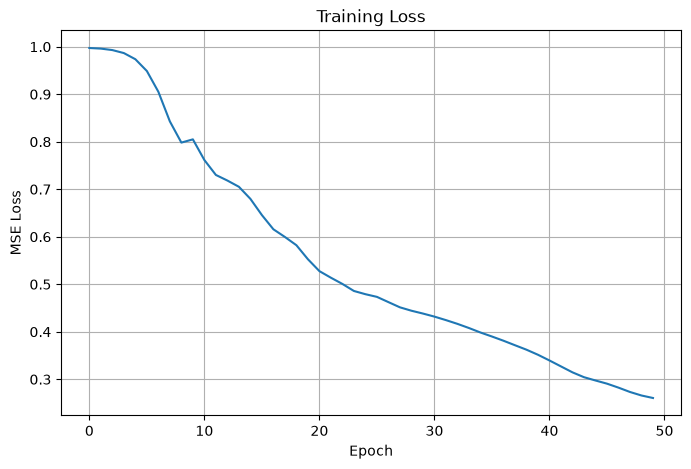

In [28]:
# ==========================================
# Training Loss Curve
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

# Reconstruction

## Generate Reconstructions

The trained AutoEncoder reconstructs each input log.

Logs that differ significantly from their reconstructed versions receive higher reconstruction errors and are more likely to represent anomalies.

In [29]:
# ==========================================
# Generate Reconstructions
# ==========================================

model.eval()

with torch.no_grad():
    reconstructed = model(X_tensor)

print("Reconstruction completed!")

Reconstruction completed!


In [31]:
# ==========================================
# Reconstruction Error
# ==========================================

reconstruction_error = torch.mean(
    (X_tensor - reconstructed) ** 2,
    dim=1
)

reconstruction_error = reconstruction_error.cpu().numpy()

print(reconstruction_error[:10])

[0.16088341 0.09627909 0.68958324 0.08351865 0.05597826 0.07189434
 0.07128944 0.34807444 0.19966918 0.17845875]


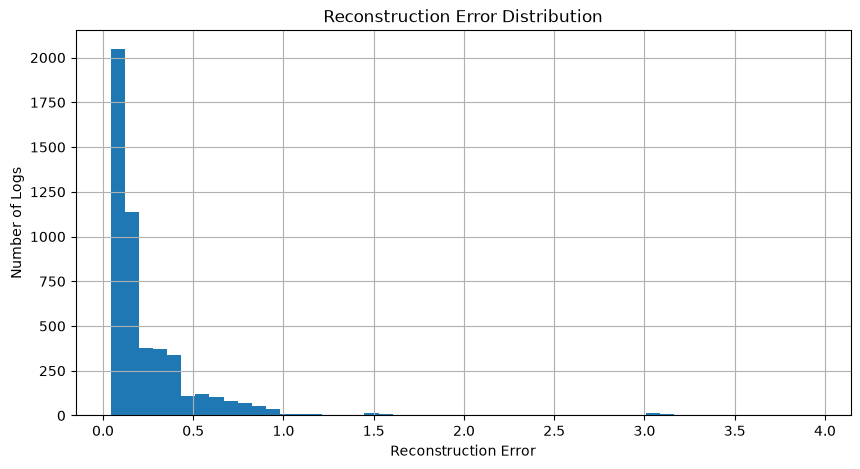

In [32]:
# ==========================================
# Distribution of Reconstruction Error
# ==========================================

plt.figure(figsize=(10,5))

plt.hist(
    reconstruction_error,
    bins=50
)

plt.title("Reconstruction Error Distribution")

plt.xlabel("Reconstruction Error")

plt.ylabel("Number of Logs")

plt.grid(True)

plt.show()

In [33]:
# ==========================================
# Anomaly Threshold
# ==========================================

threshold = np.percentile(
    reconstruction_error,
    95
)

print("Threshold :", threshold)


Threshold : 0.7503303


In [34]:
# ==========================================
# Detect Anomalies
# ==========================================

df["AnomalyScore"] = reconstruction_error

df["IsAnomaly"] = (
    reconstruction_error > threshold
)

df.head()


,Component,Line_Number,Severity,Username,AccountID,Originating_Address,Destination_Address,TPS,Queue_Count,Packet_Number,...,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,AnomalyScore,IsAnomaly
0,0,1321,0,0,0.0,0,0,0.0,0.0,0.0,...,-0.205033,-0.322827,-0.015645,0.238402,0.099279,-0.432111,0.299809,0.586938,0.160883,False
1,0,448,0,0,0.0,0,0,0.0,1.0,0.0,...,-0.185267,-0.142907,0.149421,0.030976,0.066475,-0.186554,-0.010033,0.883851,0.096279,False
2,1,107,0,5,0.0,53,0,0.0,0.0,0.0,...,-0.097869,-0.189050,-0.061228,0.038011,0.069819,-0.488632,0.314820,0.724190,0.689583,False
3,1,124,0,0,0.0,0,255653530543,0.0,0.0,0.0,...,-0.211178,-0.328493,-0.108629,0.194364,-0.172935,-0.432979,0.331966,0.621950,0.083519,False
4,0,4785,0,0,0.0,0,0,0.0,0.0,0.0,...,0.032326,0.036039,-0.193862,0.247105,0.081061,-0.595770,0.288617,0.752470,0.055978,False


In [35]:
# ==========================================
# Count Anomalies
# ==========================================

print(df["IsAnomaly"].value_counts())

IsAnomaly
False    4697
True      248
Name: count, dtype: int64


In [36]:
# ==========================================
# Percentage of Anomalies
# ==========================================

anomaly_percentage = (
    df["IsAnomaly"].mean()
) * 100

print(
    f"Anomaly Percentage : {anomaly_percentage:.2f}%"
)

Anomaly Percentage : 5.02%


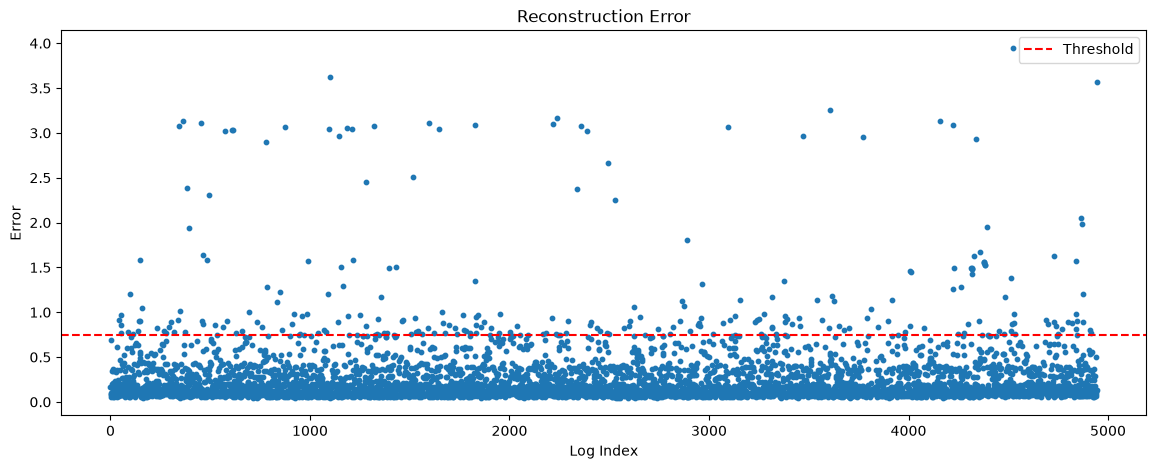

In [37]:
# ==========================================
# Reconstruction Error Plot
# ==========================================

plt.figure(figsize=(14,5))

plt.scatter(
    range(len(reconstruction_error)),
    reconstruction_error,
    s=10
)

plt.axhline(
    threshold,
    color="red",
    linestyle="--",
    label="Threshold"
)

plt.title("Reconstruction Error")

plt.xlabel("Log Index")

plt.ylabel("Error")

plt.legend()

plt.show()

In [38]:
# ==========================================
# Save Results
# ==========================================

from pathlib import Path

Path("../data/processed").mkdir(
    exist_ok=True
)

df.to_csv(
    "../data/processed/anomaly_scores.csv",
    index=False
)

print("Anomaly scores saved successfully!")

Anomaly scores saved successfully!


In [39]:
# ==========================================
# Save AutoEncoder Model
# ==========================================

Path("../models").mkdir(
    exist_ok=True
)

torch.save(
    model.state_dict(),
    "../models/log_autoencoder.pth"
)

print("Model saved successfully!")

Model saved successfully!
